In [1]:
!pip install -q mne numpy matplotlib scipy scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 63.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import mne

from sklearn.preprocessing import StandardScaler

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
from google.colab import files

uploaded = files.upload()

print("\nUploaded files:")

for filename in uploaded.keys():
    print(filename)

Saving S001R02.edf to S001R02.edf

Uploaded files:
S001R02.edf


In [4]:
edf_file = "/content/S001R02.edf"

if os.path.exists(edf_file):
    print("EDF file found!")
    print(edf_file)
else:
    print("EDF file not found!")

EDF file found!
/content/S001R02.edf


In [5]:
raw = mne.io.read_raw_edf(
    edf_file,
    preload=True,
    verbose=False
)

print("EEG file loaded successfully!")

EEG file loaded successfully!


In [6]:
print("=" * 50)
print("EEG INFORMATION")
print("=" * 50)

print("Number of channels :", len(raw.ch_names))
print("Sampling frequency :", raw.info["sfreq"], "Hz")
print("Duration           :", round(raw.times[-1], 2), "seconds")

print("\nChannel names:")
print(raw.ch_names)

EEG INFORMATION
Number of channels : 64
Sampling frequency : 160.0 Hz
Duration           : 60.99 seconds

Channel names:
['Fc5.', 'Fc3.', 'Fc1.', 'Fcz.', 'Fc2.', 'Fc4.', 'Fc6.', 'C5..', 'C3..', 'C1..', 'Cz..', 'C2..', 'C4..', 'C6..', 'Cp5.', 'Cp3.', 'Cp1.', 'Cpz.', 'Cp2.', 'Cp4.', 'Cp6.', 'Fp1.', 'Fpz.', 'Fp2.', 'Af7.', 'Af3.', 'Afz.', 'Af4.', 'Af8.', 'F7..', 'F5..', 'F3..', 'F1..', 'Fz..', 'F2..', 'F4..', 'F6..', 'F8..', 'Ft7.', 'Ft8.', 'T7..', 'T8..', 'T9..', 'T10.', 'Tp7.', 'Tp8.', 'P7..', 'P5..', 'P3..', 'P1..', 'Pz..', 'P2..', 'P4..', 'P6..', 'P8..', 'Po7.', 'Po3.', 'Poz.', 'Po4.', 'Po8.', 'O1..', 'Oz..', 'O2..', 'Iz..']


In [7]:
print("EEG ANNOTATIONS")
print("=" * 50)

for onset, duration, description in zip(
    raw.annotations.onset,
    raw.annotations.duration,
    raw.annotations.description
):

    print(
        "Onset:",
        onset,
        "| Duration:",
        duration,
        "| Event:",
        description
    )

EEG ANNOTATIONS
Onset: 0.0 | Duration: 60.2 | Event: T0


Using matplotlib as 2D backend.
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


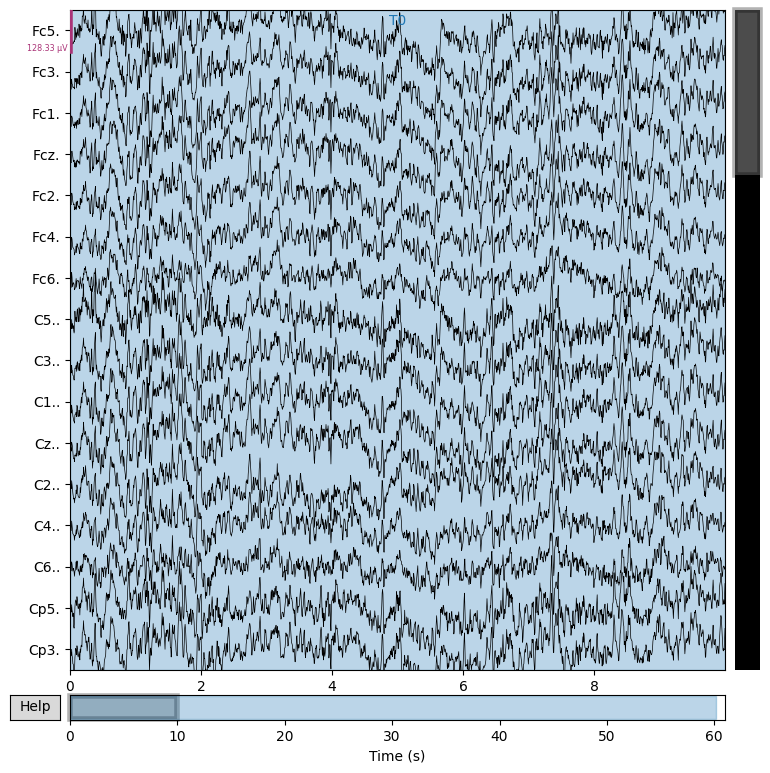

In [8]:
raw.plot(
    duration=10,
    n_channels=16,
    scalings="auto"
)

plt.show()

In [9]:
raw_filtered = raw.copy()

print("Created a copy for preprocessing.")

Created a copy for preprocessing.


In [10]:
raw_filtered.filter(
    l_freq=1,
    h_freq=40,
    verbose=False
)

print("1–40 Hz band-pass filtering completed!")

1–40 Hz band-pass filtering completed!


For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


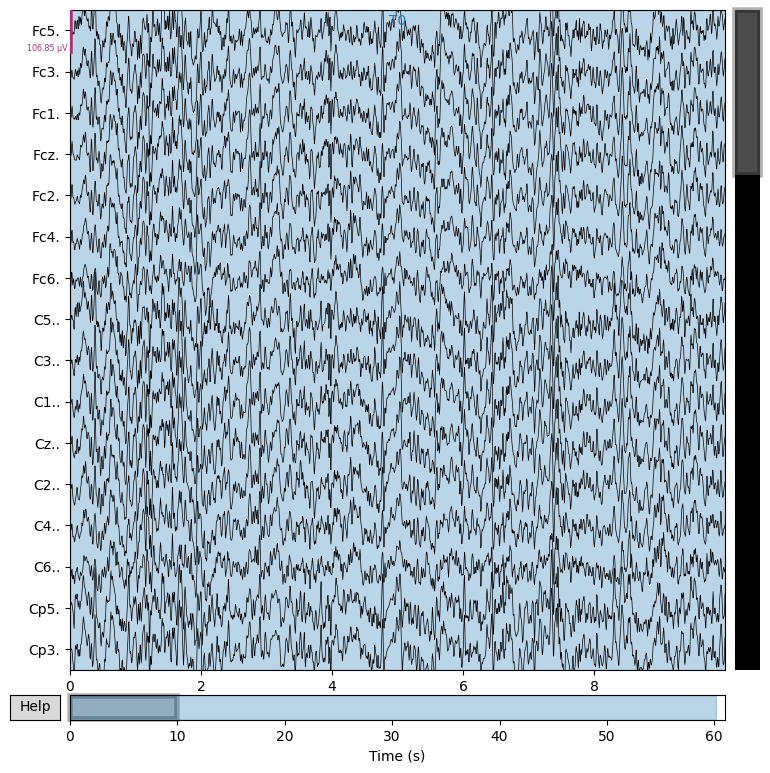

In [11]:
raw_filtered.plot(
    duration=10,
    n_channels=16,
    scalings="auto"
)

plt.show()

In [12]:
data = raw_filtered.get_data()

print("EEG data shape:")
print(data.shape)

EEG data shape:
(64, 9760)


In [13]:
n_channels = data.shape[0]
n_samples = data.shape[1]

fs = raw_filtered.info["sfreq"]

print("Number of channels :", n_channels)
print("Number of samples  :", n_samples)
print("Sampling frequency :", fs, "Hz")

Number of channels : 64
Number of samples  : 9760
Sampling frequency : 160.0 Hz


In [14]:
channel_name = "Fc5."

channel_index = raw_filtered.ch_names.index(
    channel_name
)

signal = data[channel_index]

print("Selected channel:", channel_name)
print("Channel index:", channel_index)
print("Number of samples:", len(signal))

Selected channel: Fc5.
Channel index: 0
Number of samples: 9760


In [15]:
duration = 4

number_of_samples = int(
    duration * fs
)

signal_4sec = signal[:number_of_samples]

print("Duration:", duration, "seconds")
print("Samples:", len(signal_4sec))

Duration: 4 seconds
Samples: 640


In [16]:
time = np.arange(
    len(signal_4sec)
) / fs

print("Time axis created.")
print("Start:", time[0], "seconds")
print("End:", time[-1], "seconds")

Time axis created.
Start: 0.0 seconds
End: 3.99375 seconds


In [17]:
scaler = StandardScaler()

signal_normalized = scaler.fit_transform(
    signal_4sec.reshape(-1, 1)
).flatten()

print("Signal normalization completed.")

print("Mean:",
      round(signal_normalized.mean(), 4))

print("Standard deviation:",
      round(signal_normalized.std(), 4))

Signal normalization completed.
Mean: -0.0
Standard deviation: 1.0


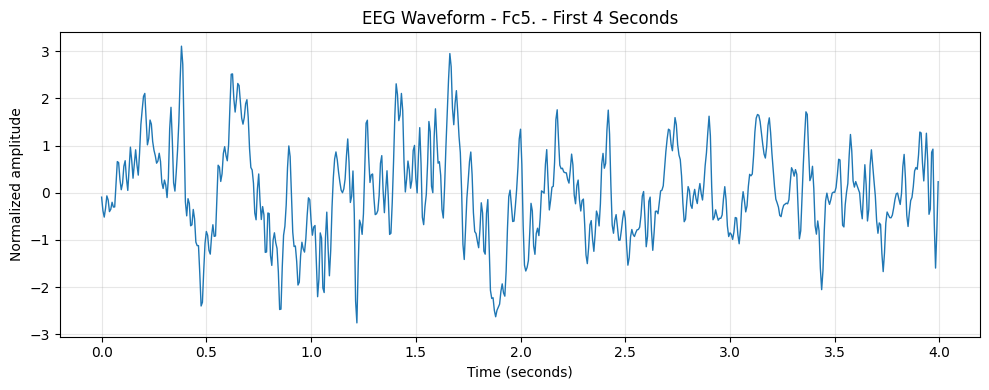

In [18]:
plt.figure(figsize=(10, 4))

plt.plot(
    time,
    signal_normalized,
    linewidth=1
)

plt.xlabel("Time (seconds)")
plt.ylabel("Normalized amplitude")

plt.title(
    f"EEG Waveform - {channel_name} - First 4 Seconds"
)

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

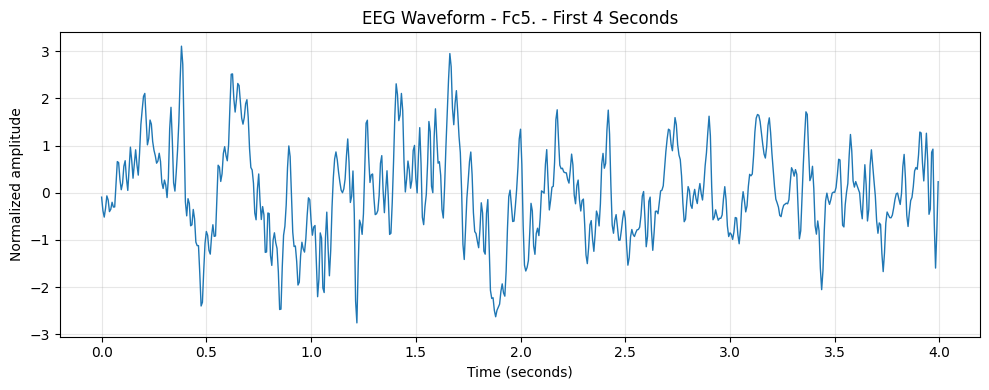

Image saved successfully!
/content/S001R02_waveform.png


In [19]:
output_file = "/content/S001R02_waveform.png"

plt.figure(figsize=(10, 4))

plt.plot(
    time,
    signal_normalized,
    linewidth=1
)

plt.xlabel("Time (seconds)")
plt.ylabel("Normalized amplitude")

plt.title(
    f"EEG Waveform - {channel_name} - First 4 Seconds"
)

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    output_file,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Image saved successfully!")
print(output_file)

In [20]:
output_folder = "/content/EEG_Waveform_Dataset"

os.makedirs(
    output_folder,
    exist_ok=True
)

print("Dataset folder created:")
print(output_folder)

Dataset folder created:
/content/EEG_Waveform_Dataset


In [21]:
epoch_duration = 4

samples_per_epoch = int(
    epoch_duration * fs
)

n_epochs = len(signal) // samples_per_epoch

print("Epoch duration:", epoch_duration, "seconds")
print("Samples per epoch:", samples_per_epoch)
print("Number of complete epochs:", n_epochs)

Epoch duration: 4 seconds
Samples per epoch: 640
Number of complete epochs: 15


In [22]:
print("Generating EEG waveform images...")

for epoch_number in range(n_epochs):

    start = epoch_number * samples_per_epoch

    end = start + samples_per_epoch

    epoch_signal = signal[
        start:end
    ]

    # Normalize
    scaler = StandardScaler()

    epoch_normalized = scaler.fit_transform(
        epoch_signal.reshape(-1, 1)
    ).flatten()

    # Time axis
    epoch_time = np.arange(
        samples_per_epoch
    ) / fs

    # Image filename
    filename = os.path.join(
        output_folder,
        f"epoch_{epoch_number:04d}.png"
    )

    # Plot
    plt.figure(figsize=(5, 4))

    plt.plot(
        epoch_time,
        epoch_normalized,
        linewidth=1
    )

    plt.axis("off")

    plt.tight_layout(pad=0)

    plt.savefig(
        filename,
        dpi=150,
        bbox_inches="tight",
        pad_inches=0
    )

    plt.close()

print("All waveform images generated!")

Generating EEG waveform images...
All waveform images generated!


In [23]:
image_files = [
    file
    for file in os.listdir(output_folder)
    if file.endswith(".png")
]

print("Total waveform images:",
      len(image_files))

Total waveform images: 15


Displaying:
/content/EEG_Waveform_Dataset/epoch_0000.png


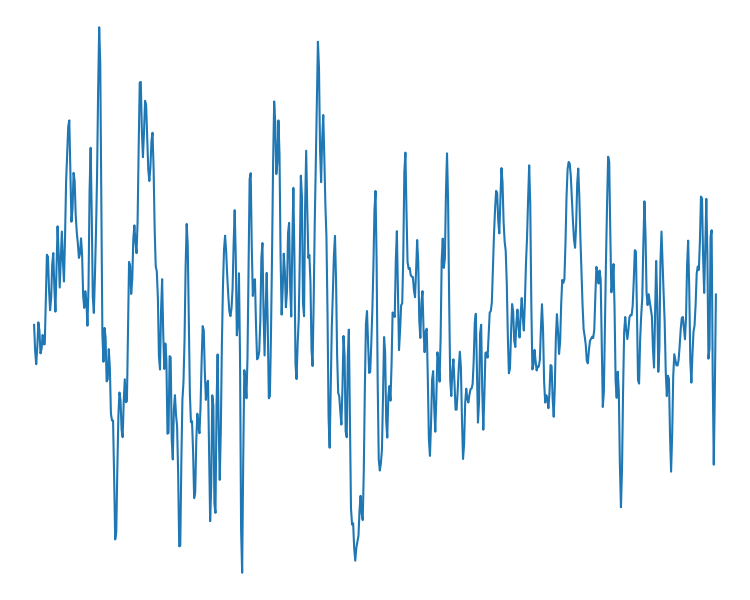

In [24]:
from IPython.display import display, Image

first_image = os.path.join(
    output_folder,
    sorted(image_files)[0]
)

print("Displaying:")
print(first_image)

display(
    Image(filename=first_image)
)

epoch_0000.png


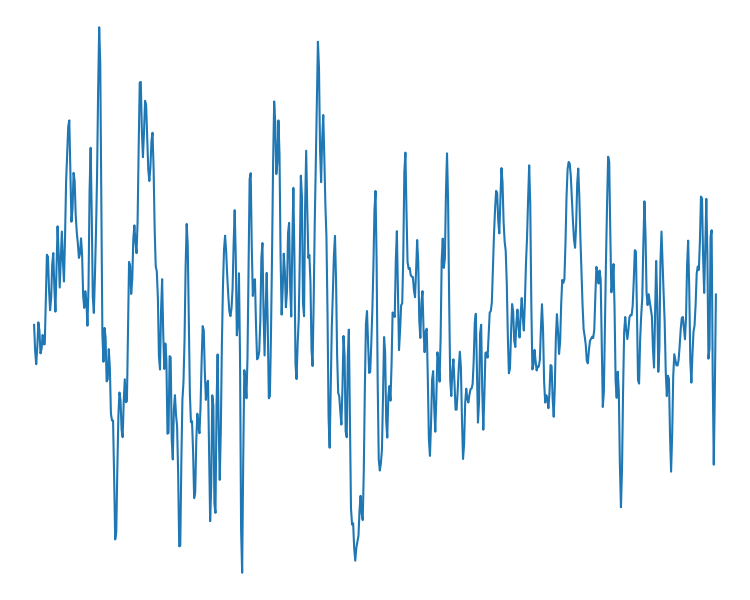

epoch_0001.png


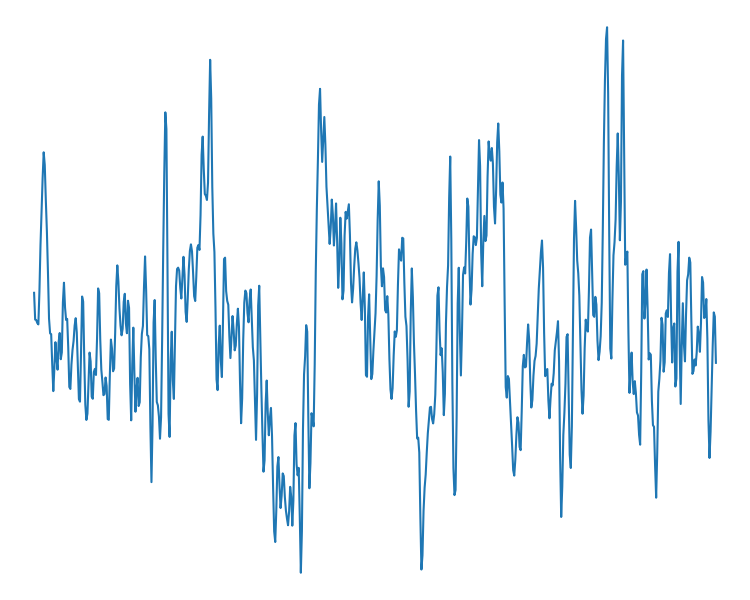

epoch_0002.png


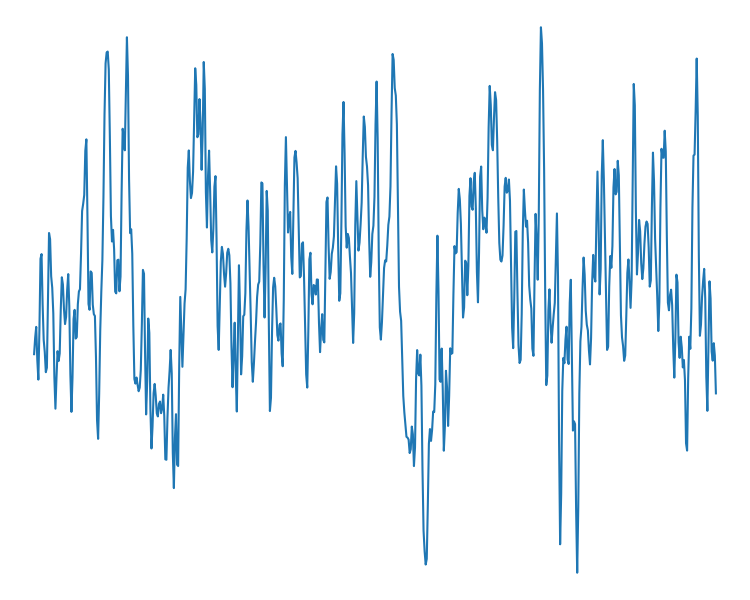

epoch_0003.png


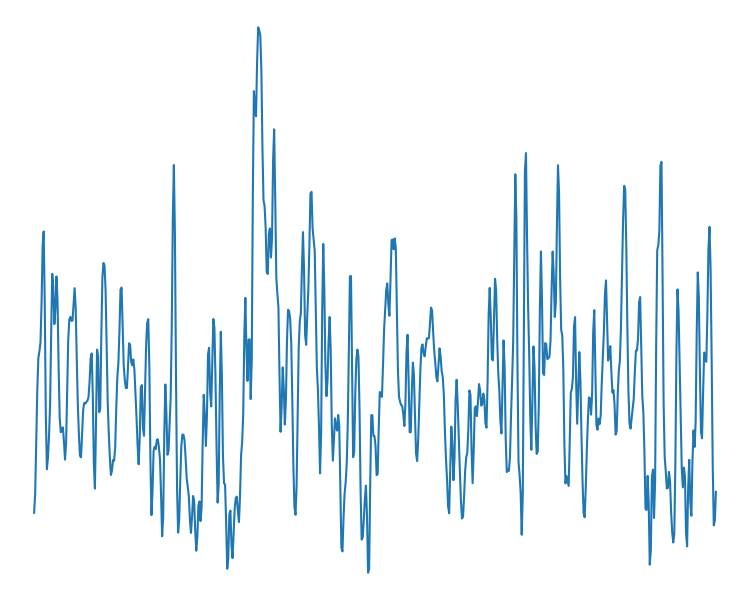

epoch_0004.png


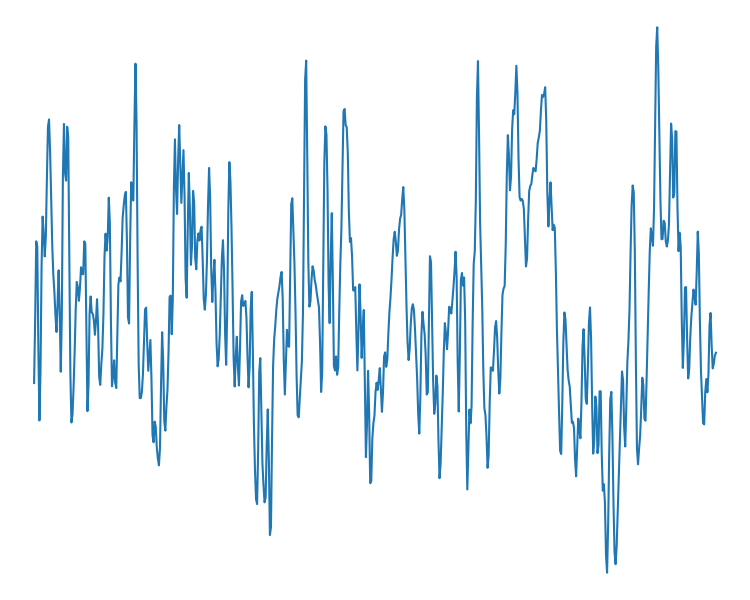

In [25]:
from IPython.display import display, Image

for filename in sorted(image_files)[:5]:

    image_path = os.path.join(
        output_folder,
        filename
    )

    print(filename)

    display(
        Image(filename=image_path)
    )